<!-- SPDX-FileCopyrightText: 2026 Orbital Research Cluster for Celestial Applications (ORCCA) Lab, University of Colorado at Boulder -->
<!-- SPDX-License-Identifier: ISC -->
# Propagation and Trajectory
---
*Last revised 2026*

## What this notebook covers
The full propagation pipeline: defining the state, choosing a force model,
running the integrator, writing the result to a SPICE SPK kernel, and
visualizing the trajectory.

### Topics
| # | Topic |
|---|-------|
| 1 | Spacecraft and initial conditions |
| 2 | `StateDefinition` — all estimability / dynamics combinations |
| 3 | Force models — Keplerian, third-body, cannonball SRP, N-plate SRP, spherical harmonics |
| 4 | `Trajectory` — SPK export and orbit plot |
| 5 | IAS15 integrator — comparison with DOP853 |

## 0. Imports and Setup

In [1]:
import scarabaeus as scb
import supplementary as supp

import time, warnings
from pathlib import Path
import numpy as np

# load tutorial data
data = supp.load_data()

# define units and frames
kg, m, km, sec, hr, day, rad, deg, N, unitless = scb.Units.get_units(
    ["kg", "m", "km", "sec", "hr", "day", "rad", "deg", "N", "unitless"]
)
frame = scb.Frame('J2000')

# load kernels
scb.SpiceManager.clear_kernels()
scb.SpiceManager.load_kernel_from_mkfile(data.mk.path)

SCB supplementary data up to date.


---
## 1. Spacecraft and Initial Conditions

### Spacecraft

`Spacecraft` bundles the physical properties used by the equations of motion.

| Parameter | Value | Role |
|---|---|---|
| `tot_mass` | 2000 kg (1500 dry + 500 fuel) | Gravitational and SRP acceleration |
| `area` | 1×10⁻⁶ km² | Cannonball SRP cross-section |
| `ref_coeff` | 1.5 | Reflectivity coefficient |
| `n_plate_model` | generic 11-plate config | Geometry-aware SRP (§3.4) |
| `attitudeMode` | `"nadir_pointing_to_sun"` | Body-frame orientation rule |
| `nadirPointingAxis` | `[-1, 0, 0]` | Body axis pointing toward Sun |

In [2]:
dry_mass  = scb.ArrayWUnits(1500.0, kg)
fuel_mass = scb.ArrayWUnits(500.0,  kg)
area      = scb.ArrayWUnits(1e-6,   km**2)
ref_coeff = scb.ArrayWUnits(1.5,    unitless)

# ── N-plate model ─────────────────────────────────────────────────
# n_plate = scb.nPlateModel(
#     'data/dynamic_setup/nplate_coefficients/generic_nplate_config.json'
# )
n_plate = scb.nPlateModel(data.OREx_nplate.path)

# ── spacecraft ────────────────────────────────────────────────────
orcca_sc = scb.Spacecraft(
    name             = 'ORCCA_SC',
    spice_id         = -1000,
    tot_mass         = dry_mass + fuel_mass,
    area             = area,
    ref_coeff        = ref_coeff,
    n_plate_model    = n_plate,
    attitudeMode     = 'nadir_pointing_to_sun',
    nadirPointingAxis= np.array([-1, 0, 0]),
)
print(orcca_sc)

-1000 ORCCA_SC


### Initial Conditions and Time Span

The scenario: heliocentric orbit near 1 AU, 2021 January 1 → February 1, sampled every hour.
`EpochArray` with `sys="TDB"` wraps the SPICE ET values so the propagator can iterate over them.

In [3]:
sun = scb.CelestialBody.from_constants('SUN')

# ── initial position and velocity (J2000, Sun-centred) ────────────
pos0 = scb.ArrayWFrame(
    np.array([-1.1123095885148e8, 8.9094345479316e7, 3.8656500948069e7]), km, frame
)
vel0 = scb.ArrayWFrame(
    np.array([-20.6936999825159, -16.7800270812616, -6.6437327193572]), km / sec, frame
)

# ── epoch array: 2021-Jan-01 → 2021-Feb-01, 1-hour steps
epochs = scb.EpochArray.interval('2021 January 1, 00:00:00', '2021 February 1, 00:00:00',
                                 dt = scb.ArrayWUnits(1, hr), sys = 'TDB')

print(f"Span : {len(epochs)} epochs,  "
      f"{epochs.duration(day)}-day arc,  1-hour step")

Span : 744 epochs,  30.958333333333332 day-day arc,  1-hour step


---
## 2. StateDefinition Combinations

A `StateDefinition` is an ordered list of state components.  Each component is a 6-tuple:

```python
(name, dimension, estimability, dynamics_type, body, initial_value)
```

The two key fields — `estimability` and `dynamics_type` — jointly control how a component
interacts with the **propagator** and the **orbit-determination filter**:

| `estimability` | `dynamics_type` | ODE integrates? | Filter corrects? | Typical use |
|---|---|:---:|:---:|---|
| `"estimated"` | `"dynamic"` | ✓ | ✓ | Position, velocity |
| `"estimated"` | `"static"` | ✗ (constant) | ✓ | SRP scale η, drag Cd, biases |
| `"considered"` | `"static"` | ✗ | ✗ (cov. only) | Schmidt–Kalman consider parameters |

### Two Construction Styles

`StateDefinition` supports a **component** API (explicit tuples) and a **fluent** API
(method chaining).  Both produce identical objects; choose whichever is more readable.

```python
# Component style (explicit)
state = scb.StateDefinition.from_components([
    ("position", 3, "estimated", "dynamic", sc, pos0),
    ("velocity", 3, "estimated", "dynamic", sc, vel0),
    ("eta_srp",  1, "estimated", "static",  sc, eta),
])

# Fluent style (chained)
state = (
    scb.StateDefinition()
    .position(sc, pos0)
    .velocity(sc, vel0)
    .param("eta_srp", sc, eta, estimation="estimated", dynamics="static")
)
```

In [4]:
eta_val = scb.ArrayWFrame(scb.ArrayWUnits(np.array([1.0]), None), frame)

# ── 1. estimated + dynamic  (standard pos/vel, propagated and filter-correctable)
state_dyn = scb.StateDefinition.from_components([
    ("position", 3, "estimated", "dynamic", orcca_sc, pos0),
    ("velocity", 3, "estimated", "dynamic", orcca_sc, vel0),
])

# ── 2. estimated + static  (SRP scale: carried constant, filter-correctable)
state_eta_est = scb.StateDefinition.from_components([
    ("position", 3, "estimated", "dynamic", orcca_sc, pos0),
    ("velocity", 3, "estimated", "dynamic", orcca_sc, vel0),
    ("eta_srp",  1, "estimated", "static",  orcca_sc, eta_val),
])

# ── 3. considered + static  (Schmidt parameter: uncertainty inflates covariance,
#                             but value is never updated by the filter)
state_eta_con = scb.StateDefinition.from_components([
    ("position", 3, "estimated",  "dynamic", orcca_sc, pos0),
    ("velocity", 3, "estimated",  "dynamic", orcca_sc, vel0),
    ("eta_srp",  1, "considered", "static",  orcca_sc, eta_val),
])

# ── fluent style — equivalent to state_eta_est ────────────────────
state_fluent = (
    scb.StateDefinition()
    .position(orcca_sc, pos0)
    .velocity(orcca_sc, vel0)
    .param("eta_srp", orcca_sc, eta_val, estimation="estimated", dynamics="static")
)

# ── summary ───────────────────────────────────────────────────────
sv_dyn     = scb.StateArray(epoch=epochs[0], origin=sun, state=state_dyn)
sv_eta_est = scb.StateArray(epoch=epochs[0], origin=sun, state=state_eta_est)
sv_eta_con = scb.StateArray(epoch=epochs[0], origin=sun, state=state_eta_con)

for label, sv in [
    ("est+dynamic (pos/vel)",      sv_dyn),
    ("est+static  (eta_srp est)",  sv_eta_est),
    ("considered  (eta_srp con)",  sv_eta_con),
]:
    print(f"  {label:<38}  state dim = {sv.size}")

  est+dynamic (pos/vel)                   state dim = 6
  est+static  (eta_srp est)               state dim = 7
  considered  (eta_srp con)               state dim = 7


---
## 3. Force Models and Propagation

Every propagation is assembled from three components:

- **`StateArray`** — initial state at t₀ (wraps a `StateDefinition`)
- **`ForceModelTranslation`** — accumulates accelerations at each integration step
- **`Propagator`** — drives the ODE integrator over `tspan`, fills `propagated_state_array`

The five examples below add force-model terms progressively.

| Example | Force model | Extra flag |
|---|---|---|
| 1 | Central-body gravity (Sun) only | — |
| 2 | + Third-body perturbations | `third_bodies=[…]` |
| 3 | + Cannonball SRP | `cannonball_SRP=True` |
| 4 | + N-plate SRP | `nplate_SRP=True` |
| 5 | + Spherical-harmonic gravity | `sph_harm=True` |

### Two-body (Keplerian)

Only the Sun's point-mass gravity — the trajectory follows a Keplerian conic.
This is the baseline all other examples are compared against.

In [5]:
sv1    = scb.StateArray(epoch=epochs[0], origin=sun, state=state_dyn)
fm1    = scb.ForceModelTranslation(primary_body=orcca_sc)
prop1  = scb.Propagator(primary_body=orcca_sc, state_vector=sv1,
                         tspan=epochs, force_models=fm1)
print("── Example 1: Keplerian ──────────────────────────────────")
prop1.propagate()

── Example 1: Keplerian ──────────────────────────────────

                            Starting propagation...                             


Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

Integrating:   0%|                                             | 0.01/2674800.00 s [00:00<116:53:34]

Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

...

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]


 =================== DOP853 integration complete. ==================
Propagation complete.


### Third-body Perturbations

`third_bodies` accepts SPICE body-name strings.  SCB queries their positions from the
ephemeris at each step and adds the point-mass acceleration.
Inner planets (Mercury, Venus, Earth) are the dominant third-body terms near 1 AU.

In [6]:
third_bodies = ['MERCURY', 'VENUS', 'EARTH']

sv2   = scb.StateArray(epoch=epochs[0], origin=sun, state=state_dyn)
fm2   = scb.ForceModelTranslation(primary_body=orcca_sc, third_bodies=third_bodies)
prop2 = scb.Propagator(primary_body=orcca_sc, state_vector=sv2,
                        tspan=epochs, force_models=fm2)
print("── Example 2: Third-body ─────────────────────────────────")
prop2.propagate()

── Example 2: Third-body ─────────────────────────────────

                            Starting propagation...                             


Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

Integrating:   0%|                                             | 0.01/2674800.00 s [00:00<489:01:30]

Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

...

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]


 =================== DOP853 integration complete. ==================
Propagation complete.


### Cannonball SRP

The spacecraft is treated as a sphere:
$\mathbf{a}_\text{SRP} = -(r_\text{AU}/r)^2\, P_\odot\,(A/m)\,C_r\,\hat{\mathbf{r}}_\odot$

`eta_srp` is a static estimated scale factor included in the state so a filter can solve for it
to absorb SRP model error without re-propagating (see §2, combination 2).

In [7]:
sv3   = scb.StateArray(epoch=epochs[0], origin=sun, state=state_eta_est)
fm3   = scb.ForceModelTranslation(primary_body=orcca_sc, cannonball_SRP=True)
prop3 = scb.Propagator(primary_body=orcca_sc, state_vector=sv3,
                        tspan=epochs, force_models=fm3)
print("── Example 3: Cannonball SRP ─────────────────────────────")
prop3.propagate()

── Example 3: Cannonball SRP ─────────────────────────────

                            Starting propagation...                             


Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

Integrating:   0%|                                             | 0.01/2674800.00 s [00:00<172:34:56]

Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

...

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]


 =================== DOP853 integration complete. ==================
Propagation complete.


### N-plate SRP

Decomposes the spacecraft into flat plates; at each step, the illuminated plates are
identified and their SRP forces summed.  More accurate than cannonball for non-spherical
geometries.  The attitude mode (`nadir_pointing_to_sun`) defines body-frame orientation.

> The generic config used here does not require a C-kernel; the `UserWarning` about
> the missing attitude kernel is suppressed below.

In [8]:
sv4   = scb.StateArray(epoch=epochs[0], origin=sun, state=state_dyn)
fm4   = scb.ForceModelTranslation(primary_body=orcca_sc, nplate_SRP=True)
prop4 = scb.Propagator(primary_body=orcca_sc, state_vector=sv4,
                        tspan=epochs, force_models=fm4)
print("── Example 4: N-plate SRP ────────────────────────────────")
with warnings.catch_warnings():
    warnings.simplefilter('ignore', UserWarning)
    prop4.propagate()

── Example 4: N-plate SRP ────────────────────────────────

                            Starting propagation...                             


Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

/Users/zael5647/scarabaeus/src/scarabaeus/dynamics/ForceModelTranslation.py:849: RuntimeWarning: nadir_pointing_to_sun attitude mode not yet fully implemented for nPlateSRP. It currently produces incorrect partial derivatives.
  model_acceleration = self.force_models[model].compute_acceleration(


Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

Integrating:   0%|                                            | 0.01/2674800.00 s [00:00<1528:03:01]

...

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]


 =================== DOP853 integration complete. ==================
Propagation complete.


### Spherical-Harmonic Gravity

Augments the central-body gravity with normalized Stokes coefficients $(C_{nm}, S_{nm})$
to a chosen degree and order.  Here the SH body is **Earth** (not the Sun), which is
physically correct for an Earth-orbiting spacecraft.  For the heliocentric orbit used
throughout this notebook the SH acceleration is tiny but the API usage is identical.

In [9]:
sph = {
    'order'    : 3,
    'cs_file'  : data.earth_sph_config.path,
    'body'     : scb.CelestialBody.from_constants('EARTH'),
    'norm_flag': True,
}

sv5   = scb.StateArray(epoch=epochs[0], origin=sun, state=state_dyn)
fm5   = scb.ForceModelTranslation(
    primary_body=orcca_sc,
    sph_harm=True,
    sph_harm_order   =sph['order'],
    sph_harm_cs_file =sph['cs_file'],
    sph_harm_body    =sph['body'],
    sph_harm_norm_flag=sph['norm_flag'],
)
prop5 = scb.Propagator(primary_body=orcca_sc, state_vector=sv5,
                        tspan=epochs, force_models=fm5)
print("── Example 5: Spherical harmonics ───────────────────────")
prop5.propagate()

/Users/zael5647/scarabaeus/src/scarabaeus/dynamics/SphericalHarmonicsGravity.py:166: RuntimeWarning: SPH gravity body is 'Earth', but propagation origin is 'Sun'. The model will compute the relative vector r_eval/sph = r_eval/origin - r_sph/origin using SPICE.
  warnings.warn(


── Example 5: Spherical harmonics ───────────────────────

                            Starting propagation...                             


Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

Integrating:   0%|                                             | 0.01/2674800.00 s [00:00<231:35:00]

...

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]


 =================== DOP853 integration complete. ==================
Propagation complete.


---
## 4. Trajectory and Visualization

`scb.Trajectory` wraps `propagated_state_array` and writes it to a SPICE SPK kernel via
`write_to_spk`.  Once furnised, any SPICE-aware tool can query the spacecraft's state at
arbitrary epochs within the propagation window.

Below: the Keplerian trajectory is written, furnised, and plotted.

SPK written to /Users/zael5647/scarabaeus/docs/online_documentation/sphinx_files/_collections/tutorials/tutorial_results/prop_and_traj/keplerian_trajectory.bsp


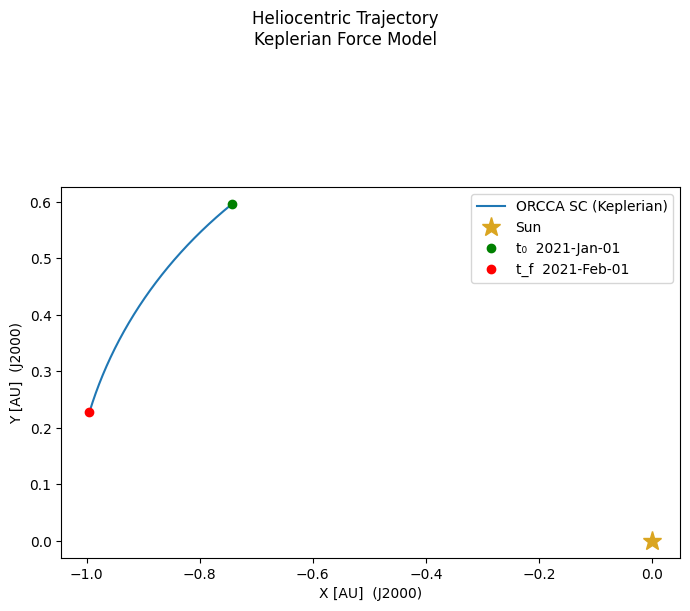

In [10]:
AU_km = 1.496e8   # km per AU

# ── write Keplerian trajectory to SPK ────────────────────────────
tut_result_path = Path.cwd() / 'tutorial_results/prop_and_traj'
tut_result_path.mkdir(parents = True, exist_ok = True)
spk_path = tut_result_path / 'keplerian_trajectory.bsp'
if spk_path.exists(): spk_path.unlink()  # remove previous spk file if it exists
traj1 = scb.Trajectory(state_array=prop1.propagated_state_array)
traj1.write_to_spk(str(spk_path))
scb.SpiceManager.load_kernel_from_mkfile(str(spk_path))
print(f"SPK written to {str(spk_path)}")

# ── query positions at each epoch ────────────────────────────────
positions = np.array([
    scb.SpiceManager.get_state(str(orcca_sc.spice_id), et, frame, sun).values[0:3]
    for et in epochs.times.values
]) / AU_km   # → AU

# plot
supp.supp_plotting.plot_simple_orbit(positions)

### Force Model Position Comparison

The table below quantifies how much each perturbation shifts the final position
after 31 days, relative to the Keplerian baseline.

In [11]:
def final_pos_km(prop, label):
    tmp_bsp = Path.cwd() / f'tutorial_results/_tmp_{label}.bsp'
    if tmp_bsp.exists(): tmp_bsp.unlink()
    scb.Trajectory(state_array=prop.propagated_state_array).write_to_spk(str(tmp_bsp))
    scb.SpiceManager.load_kernel_from_mkfile(str(tmp_bsp))
    pos = scb.SpiceManager.get_state(
        str(orcca_sc.spice_id), epochs.times.values[-1], frame, sun
    ).values[0:3]
    tmp_bsp.unlink()
    return np.array(pos)

labels = ['Keplerian', 'Third-body', 'Cannonball SRP', 'N-plate SRP', 'Sph. harmonics']
pos_f  = [final_pos_km(p, f'ex{i+1}') for i, p in enumerate([prop1, prop2, prop3, prop4, prop5])]
pos_kep = pos_f[0]

print(f"\n  {'Force model':<20}  {'|Δr| vs Keplerian [km]':>24}")
print("  " + "-" * 48)
for lbl, pos in zip(labels, pos_f):
    print(f"  {lbl:<20}  {np.linalg.norm(pos - pos_kep):>20.3f} km")


  Force model             |Δr| vs Keplerian [km]
  ------------------------------------------------
  Keplerian                            0.000 km
  Third-body                         206.647 km
  Cannonball SRP                      12.574 km
  N-plate SRP                          4.057 km
  Sph. harmonics                20887334.782 km


### Parameters JSON Sidecar and `Trajectory.get_state`

`write_to_spk` always writes a `<name>_parameters.json` sidecar alongside the `.bsp`
whenever the trajectory carries estimated parameters (any component beyond position and
velocity).  The JSON stores the full time history of every parameter so they survive
the SPK round-trip.

| File written | Content | Always? |
|---|---|:---:|
| `<name>.bsp` | Position + velocity (SPICE type-9 Lagrange) | ✓ |
| `<name>_parameters.json` | Parameter time-series + state definition | only if params present |
| `<name>_settings.json` | Propagator force-model settings | only if settings present |
| `<name>_mass_profile.json` | Spacecraft mass polynomial | only if mass profile present |

Once the SPK is furnised, **`Trajectory.get_state(epoch)`** is the right way to query
the trajectory — it returns a dict with `"position"`, `"velocity"`, and `"parameters"`
(read back from the JSON sidecar), unlike the raw `SpiceManager.get_state` which only
returns the 6-state from SPICE.

In [12]:
import json

# ── write trajectory with eta_srp parameter (prop3 = cannonball SRP) ─
spk_params = Path.cwd() / f'tutorial_results/srp_trajectory.bsp'
if spk_params.exists(): spk_params.unlink()

traj3 = scb.Trajectory(state_array=prop3.propagated_state_array)
traj3.write_to_spk(str(spk_params))

# ── show which sidecar files were created ────────────────────────────
base = str(spk_params).replace('.bsp', '')
sidecars = ['_parameters.json', '_settings.json', '_mass_profile.json']
print("Files written:")
for ext in ['.bsp'] + sidecars:
    fpath = base + ext
    # if os.path.isfile(fpath):
    #     print(f"  {os.path.basename(fpath)}  ({os.path.getsize(fpath):,} bytes)")
    if Path(base + ext).exists():
        print(f"  {Path(fpath).name}  ({Path(fpath).stat().st_size:,} bytes)")

# ── inspect the parameters JSON ───────────────────────────────────────
with open(base + '_parameters.json') as fh:
    pj = json.load(fh)

print(f"\nparameters_def  : {pj['parameters_def']}")          # parameter names
print(f"n epochs stored : {len(pj['epochsTDB'])}")
print(f"eta_srp  t=0    : {pj['parameters'][0]}")             # first epoch value
print(f"eta_srp  t=-1   : {pj['parameters'][-1]}")            # last  epoch value

# ── furnish SPK and query via Trajectory.get_state ────────────────────
# Trajectory.get_state returns position, velocity AND the parameters
# read back from the JSON sidecar — unlike SpiceManager.get_state
# which only returns the 6-state from the SPK segment.
scb.SpiceManager.load_kernel_from_mkfile(str(spk_params))

epoch_q = epochs[100]
state   = traj3.get_state(epoch_input=epoch_q, folder_path_override = str(Path.cwd() / 'tutorial_results/'))

print(f"\nTrajectory.get_state at epoch index 100:")
print(f"  position   (km)  : {state['position'].values.round(3)}")
print(f"  velocity (km/s)  : {state['velocity'].values.round(8)}")
print(f"  parameters       : {state['parameters']}")

Files written:
  srp_trajectory.bsp  (45,056 bytes)
  srp_trajectory_parameters.json  (43,528 bytes)

parameters_def  : ['eta_srp']
n epochs stored : 744
eta_srp  t=0    : [1.0]
eta_srp  t=-1   : [1.0]

Trajectory.get_state at epoch index 100:
  position   (km)  : [-1.18379786e+08  8.28230641e+07  3.61645581e+07]
  velocity (km/s)  : [-19.0117596  -18.03971812  -7.19196188]
  parameters       : 0.9999999999999997 unitless


/Users/zael5647/scarabaeus/src/scarabaeus/timeAndFrame/SpiceManager.py:1038: RuntimeWarning: Multiple matching JSON files found. Using most recently modified file: srp_trajectory_parameters.json
  warnings.warn(


---
## 5. IAS15 Integrator

Scarabaeus ships two integrators selectable via `Propagator(..., integrator=...)`:

| Integrator | Order | Adaptive? | Description |
|---|---|---|---|
| `"DOP853"` *(default)* | 8 | ✓ | Dormand–Prince explicit Runge–Kutta (scipy) |
| `"IAS15"` | 15 | ✓ | Implicit adaptive integrator (Rein & Spiegel 2015) |

**IAS15** (Implicit integrator with Adaptive Step-size control, order 15) is a native
Scarabaeus implementation designed for long-arc, high-accuracy orbital integrations.
Because it is fully implicit and 15th-order, it conserves energy to machine precision
over many orbits — a property DOP853 cannot match.

### Current constraints

| Requirement | Why |
|---|---|
| Pos + vel state only (6 components) | IAS15 integrates `ys[0:6]`; static params are not supported yet |
| Identity initial STM | Non-identity `Φ₀` is not yet handled |

Pass `integrator="IAS15"` to any `Propagator` with a 6-state `StateArray`.

In [13]:
# ── IAS15 propagation ─────────────────────────────────────────────
# propagate_STM=False is required: IAS15 does not integrate the
# variational equations and will crash if STM propagation is enabled.
sv_ias   = scb.StateArray(epoch=epochs[0], origin=sun, state=state_dyn)
fm_ias   = scb.ForceModelTranslation(primary_body=orcca_sc)

prop_ias = scb.Propagator(
    primary_body  = orcca_sc,
    state_vector  = sv_ias,
    tspan         = epochs,
    force_models  = fm_ias,
    integrator    = 'IAS15',
    propagate_STM = False,
)

t_ias_start = time.time()
prop_ias.propagate()
t_ias = time.time() - t_ias_start

# ── DOP853 timing for comparison ─────────────────────────────────
sv_dop   = scb.StateArray(epoch=epochs[0], origin=sun, state=state_dyn)
fm_dop   = scb.ForceModelTranslation(primary_body=orcca_sc)
prop_dop = scb.Propagator(
    primary_body  = orcca_sc,
    state_vector  = sv_dop,
    tspan         = epochs,
    force_models  = fm_dop,
    integrator    = 'DOP853',
    propagate_STM = False,
)

t_dop_start = time.time()
prop_dop.propagate()
t_dop = time.time() - t_dop_start

print(f"\n  IAS15  runtime : {t_ias:.2f} s")
print(f"  DOP853 runtime : {t_dop:.2f} s")


                            Starting propagation...                             
 =================== IAS15 integration complete. ==================
Propagation complete.

                            Starting propagation...                             


Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

Integrating:   0%|                                               | 0.09/2674800.00 s [00:00<5:38:25]

Integrating:   0%|                                                     | 0.00/2674800.00 s [00:00<?]

...

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]

Integrating: 100%|███████████████████████████████████████████| 2674800.00/2674800.00 s [00:00<00:00]


 =================== DOP853 integration complete. ==================
Propagation complete.

  IAS15  runtime : 0.00 s
  DOP853 runtime : 0.02 s


In [14]:
# ── extract position histories  shape: (n_epochs, 3) ─────────────
def extract_pos(prop):
    # propagated_state_array.state[0] = position entry
    # .quantity.values has shape (n_epochs, 3)
    return np.array(prop.propagated_state_array.state[0][5].quantity.values)

pos_dop = extract_pos(prop_dop)   # (n, 3)
pos_ias = extract_pos(prop_ias)   # (n, 3)

# position difference at each epoch (km)
n       = min(len(pos_dop), len(pos_ias))
diff_km = np.linalg.norm(pos_dop[:n] - pos_ias[:n], axis=1)
t_hrs   = (epochs.times.values[:n] - epochs.times.values[0]) / 3600.0

print(f"  Max |Δr| DOP853 vs IAS15 over {epochs.duration(day)} days : {diff_km.max():.3e} km")
print(f"  Mean|Δr|                                          : {diff_km.mean():.3e} km")

  Max |Δr| DOP853 vs IAS15 over 30.958333333333332 day days : 6.358e-06 km
  Mean|Δr|                                          : 4.109e-06 km


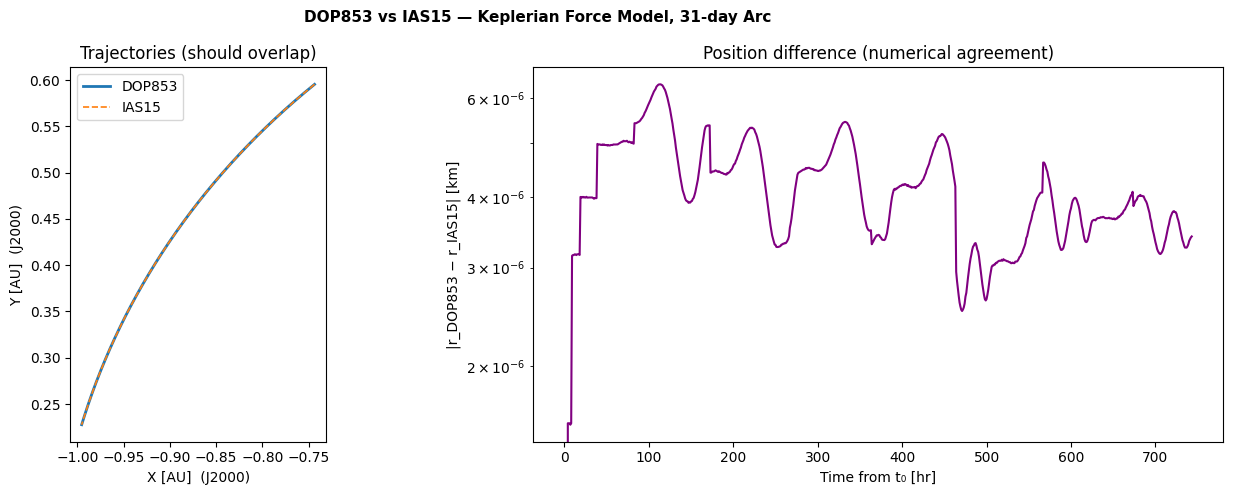

In [15]:
# comparison plot
supp.supp_plotting.plot_ias15_vs_dop853(pos_dop, pos_ias, t_hrs, diff_km, n, AU_km)